In [7]:
# Import libraries
import pandas as pd
import numpy as np

# Import dataset
df = pd.read_csv('../data/smotenc_simple_df.csv') # simple imputed dataset with SMOTENC

In [8]:
# Import train, test, split
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns='TenYearCHD')
y = df['TenYearCHD']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Import libraries
from sklearn.linear_model import LogisticRegression # Scale sensitive
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import xgboost as xgb
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier


# Dictionary of scale insensitive models
scale_ins_models = {
    'XGBoost': xgb.XGBClassifier(),
    'Gradient Boosting' : GradientBoostingClassifier(),
    'Random Forest' : RandomForestClassifier(random_state=42)
}

# Dictionary of scale sensitive models
scale_sens_models = {
    'k-Nearest Neighbors': KNeighborsClassifier(n_neighbors=8),
    'Logistic Regression' : LogisticRegression(max_iter=1000),
    'SVC' : SVC()
}

# Scale-insensitive models



--Evaluating XGBoost--

Cross-Validation Results:
Recall: 0.86, ROC-AUC: 0.94 +- 0.004

Score: 0.89
Training Recall: 0.99
Test Recall: 0.88

Classification Report:
              precision  recall  f1-score  support
0                  0.88    0.90      0.89   577.00
1                  0.89    0.88      0.89   572.00
accuracy           0.89    0.89      0.89     0.89
macro avg          0.89    0.89      0.89  1149.00
weighted avg       0.89    0.89      0.89  1149.00


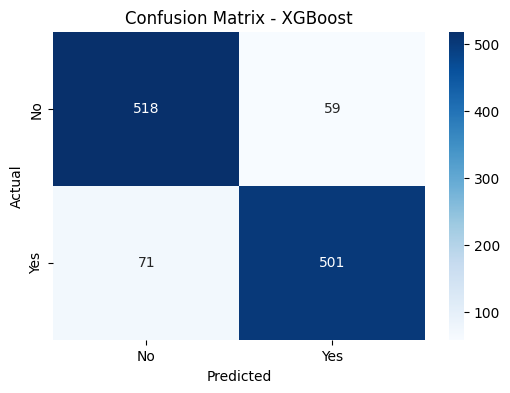

Test ROC-AUC: 0.95
Train ROC-AUC: 1.00



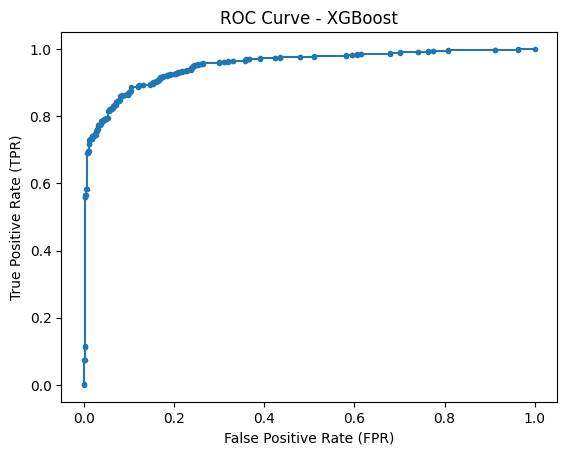

False Positive Rate (FPR): 0.000


--Evaluating Gradient Boosting--

Cross-Validation Results:
Recall: 0.83, ROC-AUC: 0.89 +- 0.013

Score: 0.83
Training Recall: 0.86
Test Recall: 0.84

Classification Report:
              precision  recall  f1-score  support
0                  0.84    0.81      0.82   577.00
1                  0.81    0.84      0.83   572.00
accuracy           0.83    0.83      0.83     0.83
macro avg          0.83    0.83      0.83  1149.00
weighted avg       0.83    0.83      0.83  1149.00


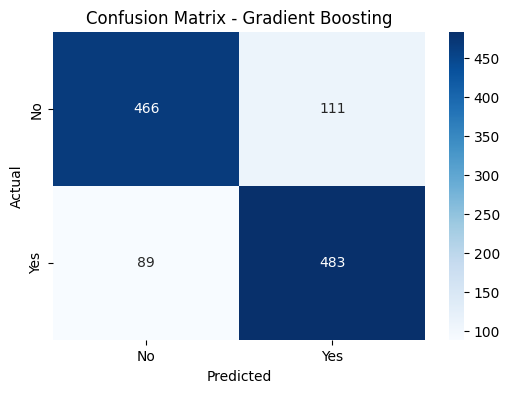

Test ROC-AUC: 0.90
Train ROC-AUC: 0.93



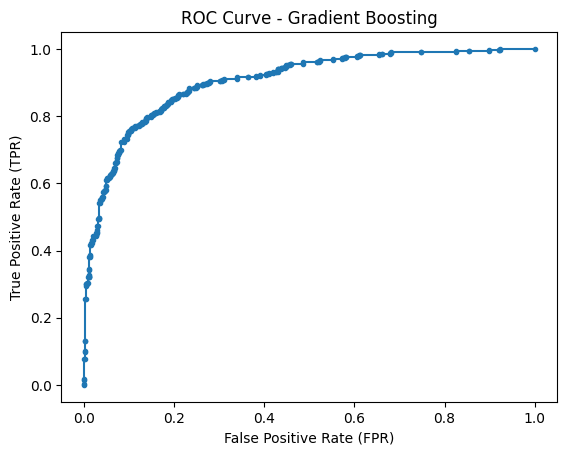

False Positive Rate (FPR): 0.000


--Evaluating Random Forest--

Cross-Validation Results:
Recall: 0.88, ROC-AUC: 0.94 +- 0.004

Score: 0.88
Training Recall: 1.00
Test Recall: 0.91

Classification Report:
              precision  recall  f1-score  support
0                  0.90    0.86      0.88   577.00
1                  0.86    0.91      0.89   572.00
accuracy           0.88    0.88      0.88     0.88
macro avg          0.88    0.88      0.88  1149.00
weighted avg       0.88    0.88      0.88  1149.00


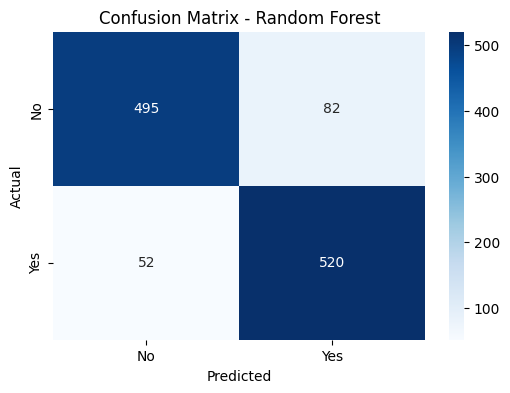

Test ROC-AUC: 0.96
Train ROC-AUC: 1.00



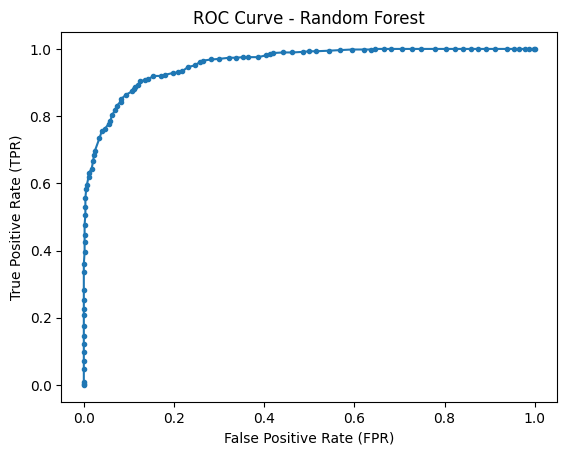

False Positive Rate (FPR): 0.000


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate

# Evaluate each model
for name, model in scale_ins_models.items():
    print(f'\n\n--Evaluating {name}--\n')
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    model.fit(X_train, y_train)
    print(f'Score: {model.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    test_roc_auc = roc_auc_score(y_test, y_test_proba)
    train_roc_auc = roc_auc_score(y_train, y_train_proba)
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate

    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1] 
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')

# Scale-sensitive



--Evaluating k-Nearest Neighbors--

Cross-Validation Results:
Recall: 0.85, ROC-AUC: 0.86 +- 0.008

Score: 0.78
Training Recall: 0.92
Test Recall: 0.89

Classification Report:
              precision  recall  f1-score  support
0                  0.86    0.66      0.75   561.00
1                  0.72    0.89      0.80   557.00
accuracy           0.78    0.78      0.78     0.78
macro avg          0.79    0.78      0.77  1118.00
weighted avg       0.79    0.78      0.77  1118.00


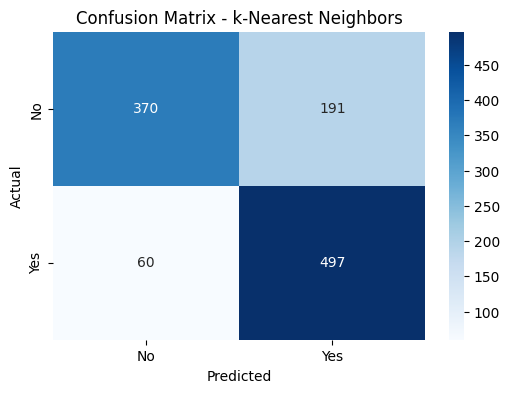

Test ROC-AUC: 0.86
Train ROC-AUC: 0.94



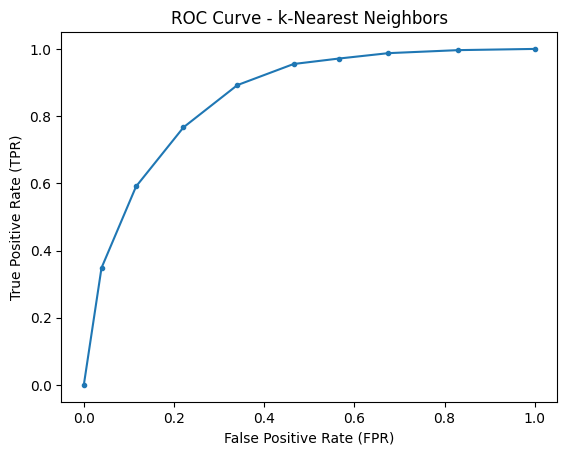

False Positive Rate (FPR): 0.039


--Evaluating Logistic Regression--

Cross-Validation Results:
Recall: 0.70, ROC-AUC: 0.75 +- 0.012

Score: 0.69
Training Recall: 0.70
Test Recall: 0.71

Classification Report:
              precision  recall  f1-score  support
0                  0.70    0.66      0.68   561.00
1                  0.68    0.71      0.70   557.00
accuracy           0.69    0.69      0.69     0.69
macro avg          0.69    0.69      0.69  1118.00
weighted avg       0.69    0.69      0.69  1118.00


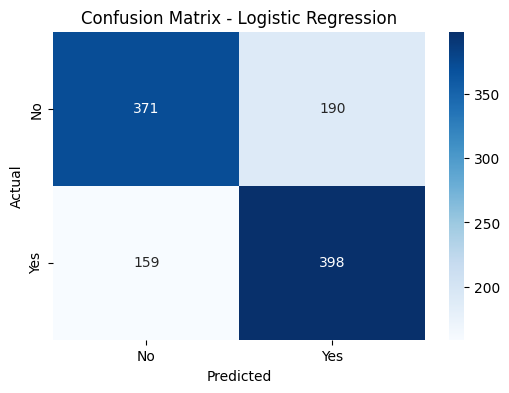

Test ROC-AUC: 0.75
Train ROC-AUC: 0.75



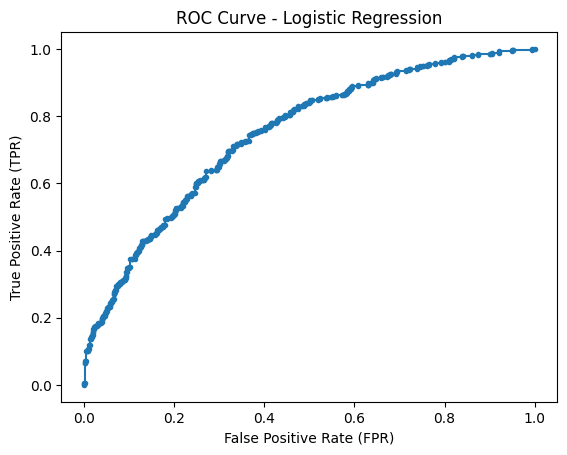

False Positive Rate (FPR): 0.000


--Evaluating SVC--

Cross-Validation Results:
Recall: 0.79, ROC-AUC: 0.82 +- 0.006

Score: 0.75
Training Recall: 0.81
Test Recall: 0.80

Classification Report:
              precision  recall  f1-score  support
0                  0.78    0.69      0.73   561.00
1                  0.72    0.80      0.76   557.00
accuracy           0.75    0.75      0.75     0.75
macro avg          0.75    0.75      0.75  1118.00
weighted avg       0.75    0.75      0.75  1118.00


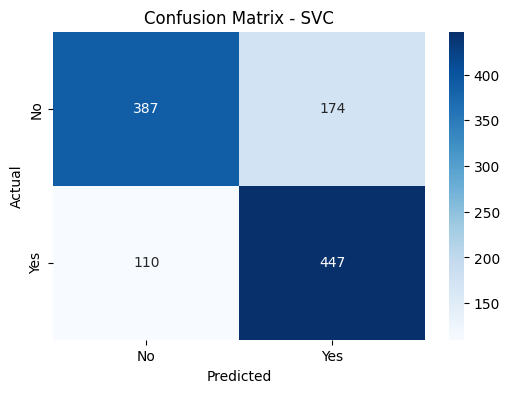

Test ROC-AUC: 0.81
Train ROC-AUC: 0.85



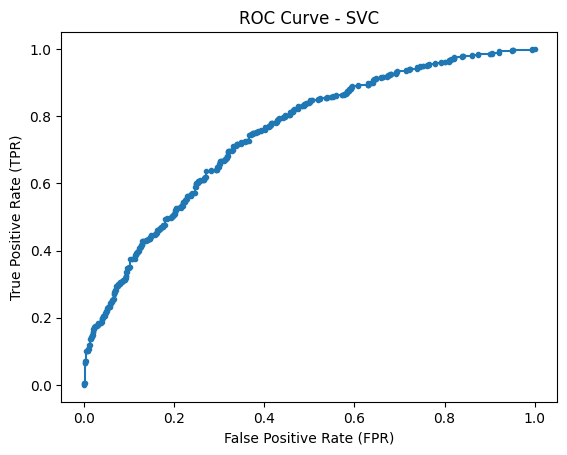

False Positive Rate (FPR): 0.000


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import recall_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# List of continuous features
cont_features = ['age', 'cigsPerDay', 'totChol', 'BMI', 'heartRate', 'glucose', 'MAP']

# Evaluate each model
for name, model in scale_sens_models.items():
    print(f'\n\n--Evaluating {name}--\n')

    # Create the pipeline with a ColumnTransformer to scale continuous features
    preprocessor = ColumnTransformer(
        transformers=[
            ('scaler', StandardScaler(), cont_features)  # Apply StandardScaler to continuous features
        ], 
        remainder='passthrough'  # Leave the other columns (non-continuous) unchanged
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),  # Apply preprocessing (scaling)
        ('model', model)  # Model step
    ])
    
    # Perform cross-validation
    cv_results = cross_validate(
        pipeline, X_train, y_train, cv=5, scoring=['recall', 'roc_auc'], return_train_score=True
    )
    print(f"Cross-Validation Results:\nRecall: {cv_results['test_recall'].mean():.2f}, "
          f"ROC-AUC: {cv_results['test_roc_auc'].mean():.2f} +- {cv_results['test_roc_auc'].std():.3f}\n")

    # Fit the model
    pipeline.fit(X_train, y_train)
    print(f'Score: {pipeline.score(X_test, y_test):.2f}')
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Get probabilities for test/train ROC-AUC calculation
    if name != 'SVC':
        y_train_proba = pipeline.predict_proba(X_train)[:, 1]
        y_test_proba = pipeline.predict_proba(X_test)[:, 1]
    else:
        train_decision_values = pipeline.decision_function(X_train)
        test_decision_values = pipeline.decision_function(X_test)

    # Recall
    train_recall = recall_score(y_train, y_train_pred)
    test_recall = recall_score(y_test, y_test_pred)
    print(f'Training Recall: {train_recall:.2f}')
    print(f'Test Recall: {test_recall:.2f}\n')

    # Classification Report
    report = classification_report(y_test, y_test_pred, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(2)
    print('Classification Report:')
    print(report_df)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # ROC-AUC
    if name != 'SVC':
        test_roc_auc = roc_auc_score(y_test, y_test_proba)
        train_roc_auc = roc_auc_score(y_train, y_train_proba)
    else:
        train_roc_auc = roc_auc_score(y_train, train_decision_values)
        test_roc_auc = roc_auc_score(y_test, test_decision_values)
        
    print(f'Test ROC-AUC: {test_roc_auc:.2f}')
    print(f'Train ROC-AUC: {train_roc_auc:.2f}\n')

    # False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    plt.plot(fpr, tpr, marker='.')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.show()
    
    # Report specific FPR
    fpr_value = fpr[1]  # Get FPR for the first threshold
    print(f'False Positive Rate (FPR): {fpr_value:.3f}')
